# __INDICE VULNERABILITÉ__ <br>Hyphothèses

In [1]:
!uv pip install statsmodels inequality plotly

Using Python 3.13.9 environment at: C:\Users\Asus\Documents\14_PrixChangementClimatique\.venv
Audited 3 packages in 45ms


## __IMPORT__

In [34]:
import re
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
import plotly.express as px

import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

# PySAL
from inequality.gini import Gini
from inequality.theil import Theil

# Sklearn
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans, HDBSCAN, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Removing warnings
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")

## __LOAD DATA__

In [3]:
# Connection
con = duckdb.connect("dev.duckdb", read_only=True)
con.sql("LOAD spatial;")  # if geospatial data needed

### Geospatial

In [4]:
dept_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/departements-avec-outre-mer.geojson"
communes_geojson_url = "https://raw.githubusercontent.com/gregoiredavid/france-geojson/master/communes-avec-outre-mer.geojson"

dept_geo = gpd.read_file(dept_geojson_url)
communes_geo = gpd.read_file(communes_geojson_url)

### Transform Data

In [5]:
query_ccr_details = """
                    SELECT
                        *
                    FROM dev.main.ccr_details
                    """

ccr_details = con.sql(query_ccr_details)
ccr_details_df = ccr_details.df()

ccr_details_df = ccr_details_df.copy()

# Date filtering
ccr_details_df = ccr_details_df[
    (ccr_details_df["date_arrete"].dt.year > 1983)
    & (ccr_details_df["date_arrete"].dt.year < 2026)
]

# ------ DATA MANIPULATION ------

# Converting to datetime
ccr_details_df["date_arrete"] = pd.to_datetime(ccr_details_df["date_arrete"])
ccr_details_df["date_debut_evenement"] = pd.to_datetime(
    ccr_details_df["date_debut_evenement"]
)
ccr_details_df["date_fin_evenement"] = pd.to_datetime(
    ccr_details_df["date_fin_evenement"]
)

# Modify Reconnue(sans impact sur la modulation)
ccr_details_df["libelle_avis"] = ccr_details_df["libelle_avis"].replace(
    {"Reconnue(sans impact sur la modulation)": "Reconnue"}
)

# Remove potential duplicated
ccr_details_df = ccr_details_df[~ccr_details_df.duplicated()]

# Segment by major perils
ccr_details_df["nom_peril"] = (
    ccr_details_df["nom_peril"]
    .mask(ccr_details_df["nom_peril"].str.contains("Inondations"), "inondations")
    .where(
        ccr_details_df["nom_peril"].str.contains("Inondations|Sécheresse"),
        "autre",
    )
)
ccr_details_df["nom_peril"] = ccr_details_df["nom_peril"].str.replace(
    "Sécheresse", "secheresse"
)

data_trans = ccr_details_df.copy()
data_trans.head()

,code_geo,nom_commune,date_debut_evenement,date_fin_evenement,date_arrete,date_parution_jo,nom_peril,franchise,libelle_avis,code_arrete
140,04077,ENTREVENNES,2024-01-01,2024-12-31,2025-12-12,2025-12-13,secheresse,-,Non reconnue,903
141,06046,COLOMARS,2023-04-01,2023-06-30,2025-12-12,2025-12-13,secheresse,Simple,Reconnue,903
142,09021,ARTIX,2024-01-01,2024-12-31,2025-12-12,2025-12-13,secheresse,-,Non reconnue,903
143,09115,ESCLAGNE,2024-01-01,2024-12-31,2025-12-12,2025-12-13,secheresse,-,Non reconnue,903
144,09122,FOIX,2024-01-01,2024-12-31,2025-12-12,2025-12-13,secheresse,-,Non reconnue,903


In [6]:
query_pprn = """
SELECT
	*
FROM dev.main.pprn_gaspar
"""

pprn = con.sql(query_pprn)
pprn_df = pprn.df()

drop_cols = [
    "libelle_organisme", "bassin_risque", "bassins_hydrographiques", 
    "procedure_revisante", "codes_revises", "procedure_revisee",
    "codes_revisants", "programmation_debut", "programmation_fin",
    "montage_debut", "montage_fin", "prescription", "etudes_hydr_debut",
    "etudes_hydr_fin", "carte_aleas_debut", "carte_aleas_fin",
    "carte_enjeux_debut", "carte_enjeux_fin", "zonage_regl_debut",
    "zonage_regl_fin", "reg_et_note_pres_debut", "reg_et_note_pres_fin",
    "concertation_debut", "concertation_fin", "consultation_debut",
    "consultation_fin", "consult_serv_debut", "consult_serv_fin",
    "enquete_publ_debut", "enquete_publ_fin", "annex_plu", "prorogation",
    "applic_antic", "deprescription"
]

pprn_df_filter = pprn_df.drop(columns=[c for c in drop_cols if c in pprn_df.columns])
pprn_df_filter = pprn_df_filter.dropna(subset="code_modele")
pprn_df_filter = pprn_df_filter[pprn_df_filter["libelle_etat"] == "Opposable"]
pprn_df_filter = pprn_df_filter[pprn_df_filter["code_risque_2_1"] != "<NA>"]

pprn_df_filter["code_risque_2_1"] = pprn_df_filter.groupby(["code_geo", "code_procedure"])["code_risque_2_1"].transform(
    lambda x: "_".join(sorted(x.astype(str).unique(), key=lambda val: float(val) if val.replace('.','',1).isdigit() else val))
)
pprn_df_filter["libelle_risque_3"] = pprn_df_filter.groupby(["code_geo", "code_procedure"])["libelle_risque_3"].transform(
    lambda x: "<br>".join(x.astype(str).unique())
)

def readable_pprn(x):
    if not isinstance(x, str): return "inconnu"
    
    mapping = {
        "I": "inondations",
        "L": "littoral",
        "RGA": "rga",
        "Mvt": "mouvement_de_terrain",
        "Multi": "couverture_multiple"
    }
    
    for key, label in mapping.items():
        if key in x:
            return label
    return "autre"

pprn_df_filter["code_modele_desc"] = pprn_df_filter["code_modele"].apply(readable_pprn)

# 6. Dédoublonnage final
pprn_df = pprn_df_filter.copy()
print(f"Avant : {pprn_df.shape}")
pprn_df = pprn_df.drop_duplicates(subset=["code_modele", "code_geo", "code_risque_2_1"])
print(f"Après : {pprn_df.shape}")

Avant : (21241, 21)
Après : (14412, 21)


In [7]:
query_geo_ccr = """
SELECT
	*
FROM dev.main.geoportail_ccr_communes
"""

geo_ccr = con.sql(query_geo_ccr)
geo_ccr_df = geo_ccr.df()


cout_cumul = {
    '≤ 100 k€': 0,
    '100 - 500 k€': 1,
    '500 - 1 000 k€': 2,
    '1000 - 5 000 k€': 3,
    '> 5 000 k€': 4
}

cols_cumul = [c for c in geo_ccr_df.columns if 'cumul' in c.lower()]

for col in cols_cumul:
    new_col_name = f"{col}_rank" 
    geo_ccr_df[new_col_name] = geo_ccr_df[col].map(cout_cumul).fillna(-1).astype(int)
    
    
cout_moyen = {
    '≤ 2,5 k€': 0,
    '2,5 - 5 k€': 1,
    '5 - 10 k€': 2,
    '10 - 20 k€': 3,
    '> 20 k€': 4
}

cols_moyen = [c for c in geo_ccr_df.columns if 'moy' in c.lower()]

for col in cols_moyen:
    new_col_name = f"{col}_rank" 
    geo_ccr_df[new_col_name] = geo_ccr_df[col].map(cout_moyen).fillna(-1).astype(int)

primes = {
    '≤ 5 k€': 0,
    '5 - 10 k€': 1,
    '10 - 25 k€': 2,
    '25 - 50 k€': 3,
    '50 - 75 k€': 4,
    '75 - 100 k€': 5,
    '100 - 500 k€': 6,
    '> 500 k€':7
}

cols_primes = [c for c in geo_ccr_df.columns if 'prime' in c.lower()]

for col in cols_primes:
    new_col_name = f"{col}_rank" 
    geo_ccr_df[new_col_name] = geo_ccr_df[col].map(primes).fillna(-1).astype(int)

sp = {
    '≤ 10 %': 0,
    '10 - 50 %': 1,
    '50 - 100 %': 2,
    '100 - 200 %': 3,
    '> 200 %': 4,
}

cols_sp = [c for c in geo_ccr_df.columns if 'sp' in c.lower()]

for col in cols_sp:
    new_col_name = f"{col}_rank" 
    geo_ccr_df[new_col_name] = geo_ccr_df[col].map(sp).fillna(-1).astype(int)

cols_rank = [c for c in geo_ccr_df.columns if 'rank' in c.lower()]

geo_ccr_df = geo_ccr_df.set_index("code_geo")
geo_ccr_df = geo_ccr_df[cols_rank]
geo_ccr_df.columns

Index(['cout_cumul_tout_rank', 'cout_cumul_tout_ino_rank',
       'cout_cumul_icb_rank', 'cout_cumul_irn_rank', 'cout_cumul_sub_rank',
       'cout_cumul_sec_rank', 'cout_cumul_mvt_rank', 'cout_cumul_sei_rank',
       'cout_cumul_ava_rank', 'cout_cumul_vcy_rank', 'cout_cumul_aut_rank',
       'cout_moy_tout_rank', 'cout_moy_tout_ino_rank', 'cout_moy_icb_rank',
       'cout_moy_irn_rank', 'cout_moy_sub_rank', 'cout_moy_sec_rank',
       'cout_moy_mvt_rank', 'cout_moy_sei_rank', 'cout_moy_ava_rank',
       'cout_moy_vcy_rank', 'cout_moy_aut_rank', 'prime_part_rank',
       'prime_pro_rank', 'prime_tot_rank', 'sp_tout_rank', 'sp_tout_ino_rank',
       'sp_icb_rank', 'sp_irn_rank', 'sp_sub_rank', 'sp_sec_rank',
       'sp_mvt_rank', 'sp_sei_rank', 'sp_ava_rank', 'sp_vcy_rank',
       'sp_aut_rank'],
      dtype='str')

### Aux Functions

In [8]:
def prepare_france_geometry(df):
    if df.crs != "EPSG:2154":
        df = df.to_crs(epsg=2154)

    df['dept_temp'] = df['code'].apply(lambda x: x[:3] if x.startswith('97') else x[:2])

    drom_configs = {
        '971': {'pos': (-150000, 6540000), 'scale': 1.3, 'name': "Guadeloupe"},
        '972': {'pos': (50000, 6540000),   'scale': 1.8, 'name': "Martinique"},
        '973': {'pos': (-150000, 6140000), 'scale': 0.25, 'name': "Guyane"},
        '974': {'pos': (-150000, 6340000), 'scale': 1, 'name': "La Réunion"},
        '976': {'pos': (50000, 6340000),   'scale': 2.5, 'name': "Mayotte"},
    }

    df_main = df[~df['dept_temp'].str.startswith('97')].copy()
    df_droms = []

    for code, cfg in drom_configs.items():
        drom = df[df['dept_temp'] == code].copy()
        if not drom.empty:
            centroid = drom.geometry.unary_union.centroid
            drom.geometry = drom.geometry.translate(xoff=-centroid.x, yoff=-centroid.y)
            drom.geometry = drom.geometry.scale(xfact=cfg['scale'], yfact=cfg['scale'], origin=(0,0))

            # Box Position
            drom.geometry = drom.geometry.translate(xoff=cfg['pos'][0], yoff=cfg['pos'][1])
            df_droms.append(drom)

    return gpd.pd.concat([df_main] + df_droms), drom_configs


def monovariate_map(df, col="taux_non_rec_global", cmap="copper_r", 
                    title="Taux de non-reconnaissance par commune", 
                    missing_color="white", norm=None, 
                    legend_label="(%)",
                    subtitle=None, linewidth=0.1, colorbar=True):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        norm=norm,
        legend=colorbar,
        legend_kwds={"shrink": 0.4, "pad": -0.05},
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth, 
    )

    cbar_ax = ax.get_figure().get_axes()[-1]
    cbar_ax.set_ylabel(f" {legend_label}", color="black")

    if subtitle:
        ax.text(0.5, 0.99, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    # Box size (width, height) in meters
    box_w, box_h = 180000, 150000 

    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)

        # Add label above each box
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15, color="black")

    null_patch = mpatches.Patch(color=missing_color, label="Pas de cas", edgecolor="black")
    leg = ax.legend(handles=[null_patch], loc="lower left", frameon=False, bbox_to_anchor=(0.5, 0.025))

    plt.setp(leg.get_texts(), color='black', fontsize=10) 

    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig


def cluster_map(df, col="clusters", cmap="Set1", 
                    title="Typologie du Risque Assurantiel", 
                    missing_color="white", 
                    legend_labels=None,
                    subtitle=None, linewidth=0.1):

    df_plot, drom_configs = prepare_france_geometry(df)

    fig, ax = plt.subplots(figsize=(14, 12))

    df_plot.plot(
        ax=ax,
        column=col,
        cmap=cmap,
        categorical=True,
        legend=False, 
        missing_kwds={"color": missing_color, "edgecolor": "black"},
        edgecolor="black",
        linewidth=linewidth, 
    )

    if subtitle:
        ax.text(0.5, 0.99, subtitle, transform=ax.transAxes, 
                fontsize=14, color='dimgray', ha='center', style='italic')

    box_w, box_h = 180000, 150000 
    for code, cfg in drom_configs.items():
        x, y = cfg['pos']
        rect = mpatches.Rectangle(
            (x - box_w/2, y - box_h/2), box_w, box_h,
            linewidth=0.5, edgecolor='gray', facecolor='none', 
            linestyle='--', alpha=0.6
        )
        ax.add_patch(rect)
        ax.text(x, y + (box_h/2) + 12500, cfg['name'], 
                fontsize=9, ha='center', color='dimgray')

    unique_clusters = sorted(df_plot[col].dropna().unique())
    colormap = plt.get_cmap(cmap)
    
    legend_handles = []
    for i, cluster_id in enumerate(unique_clusters):
        color = colormap(i / max(1, len(unique_clusters) - 1)) if len(unique_clusters) > 1 else colormap(0)
        
        label = legend_labels[cluster_id] if legend_labels and cluster_id in legend_labels else f"Cluster {int(cluster_id)}"
        
        patch = mpatches.Patch(color=color, label=label, edgecolor="black", linewidth=0.5)
        legend_handles.append(patch)

    null_patch = mpatches.Patch(color=missing_color, label="Pas de données", edgecolor="black", linewidth=0.5)
    legend_handles.append(null_patch)

    leg = ax.legend(handles=legend_handles, loc="center left", bbox_to_anchor=(0.9, 0.5), 
                    frameon=True, title="Profils de Risque", fontsize=11, title_fontsize=13)
    plt.setp(leg.get_texts(), color='black') 

    ax.set_axis_off()
    ax.set_title(title, fontsize=22, fontweight='bold', pad=15, color="black")
    
    ax.set_xlim(-280000, 1250000)
    ax.set_ylim(6000000, 7150000)

    return fig

In [9]:
def per_period(df,
               bins=[1984, 2004, 2026], 
               labels=["1984-2003", "2004-2025"],
               analysis=None,
               par_peril=False):
    
    period_data = df.copy()
    period_data["period"] = pd.cut(
        period_data["date_debut_evenement"].dt.year,
        bins=bins,
        labels=labels,
        right=False,
    )
    
    group_cols = ["code_geo", "period"]
    if par_peril:
        group_cols.append("nom_peril")
        
    period_data_counts = (
        period_data.groupby(group_cols).size().unstack(fill_value=0)
    )
    
    if analysis == "refusal":
        period_refused_counts = (
                    period_data[period_data["libelle_avis"] != "Reconnue"]
                    .groupby(group_cols)
                    .size()
                    .unstack(fill_value=0)
                )

        period_data = period_refused_counts.divide(period_data_counts).fillna(0)

    else:
        period_data = period_data_counts.copy()
    
    if par_peril:
        period_data_melt = period_data.reset_index(level=1).melt(
            id_vars="period",
            value_vars=["secheresse", "inondations"], 
            var_name="nom_peril"
        )
    else:
        period_data_melt = period_data.melt(ignore_index=False).reset_index()

    return period_data, period_data_melt


def plot_dist(df, 
              x="value", 
              hue="period",
              col=None,
              axis_labels=["Value (Counts)", "Density"],
              title="Nombre de CatNat par periode"):

    g = sns.displot(
        data=df, 
        x=x, 
        hue=hue,  
        col=col,
        height=5,            
        aspect=1.2,          
        linewidth=2,        
        alpha=0.4,
        element="step", 
        fill=True,
        common_norm=False,
        facet_kws={'sharex': False, 'sharey': False} if col else None
        )
    
    g.set_axis_labels(axis_labels[0], axis_labels[1], fontsize=12)
    g.fig.suptitle(title, fontsize=16, y=1.05)
    g._legend.set_title("Periode")
    
    return g


def stats_test(df, 
               col="value",
               labels=["1984-2003", "2004-2025"],
               group_by_col=None):

    print(f"\n{'='*40}")
    print(f" STATISTICAL TESTING ")
    print(f"{'='*40}")

    if group_by_col:
        groups = df[group_by_col].unique()
    else:
        groups = ["All Data"]
        group_by_col = "dummy"
        df["dummy"] = "All Data"

    for group in groups:
        print(f"\n>>> Analysis for: {group}")
        subset = df[df[group_by_col] == group]

        p_old = subset[subset['period'] == labels[0]][col]
        p_new = subset[subset['period'] == labels[1]][col]
        
        stat, p_value = stats.mannwhitneyu(p_old, p_new, alternative='less') 

        print(f"\n--- Mann-Whitney U Test ---")
        print(f"P-value: {p_value:.5e}")
        print("Result:", "Significant increase" if p_value < 0.05 else "No significant increase")

        print(f"\n--- Poisson GLM ---")
        try:
            model = smf.glm(formula=f"{col} ~ period", data=subset, 
                            family=sm.families.Poisson()).fit()
            print(model.summary().tables[1])
        except Exception as e:
            print(f"GLM Failed: {e}")

## Voit-on une augmentation des CatNat par communes? 

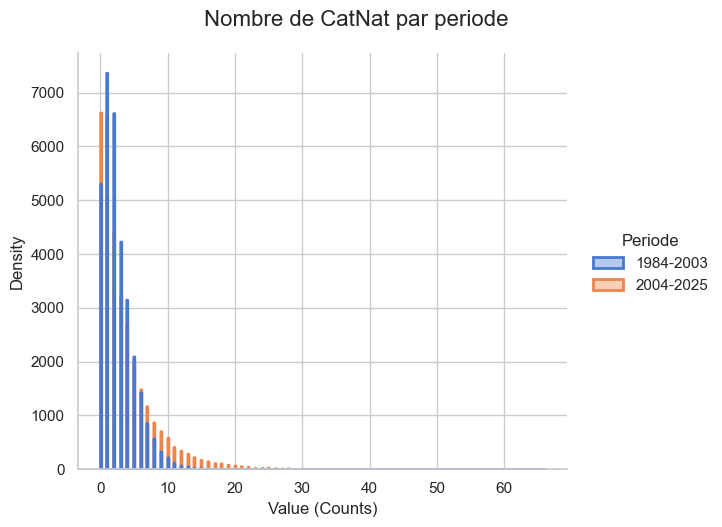


 STATISTICAL TESTING 

>>> Analysis for: All Data

--- Mann-Whitney U Test ---
P-value: 9.61619e-38
Result: Significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.9581      0.003    278.856      0.000       0.951       0.965
period[T.2004-2025]     0.3133      0.005     69.299      0.000       0.304       0.322


In [440]:
period_data, period_data_melt = per_period(data_trans,
                                           bins=[1984, 2004, 2026], 
                                           labels=["1984-2003", "2004-2025"])

plot_dist(period_data_melt)
plt.show()

stats_test(period_data_melt)

## Voit-on une augmentation du Refus par communes?

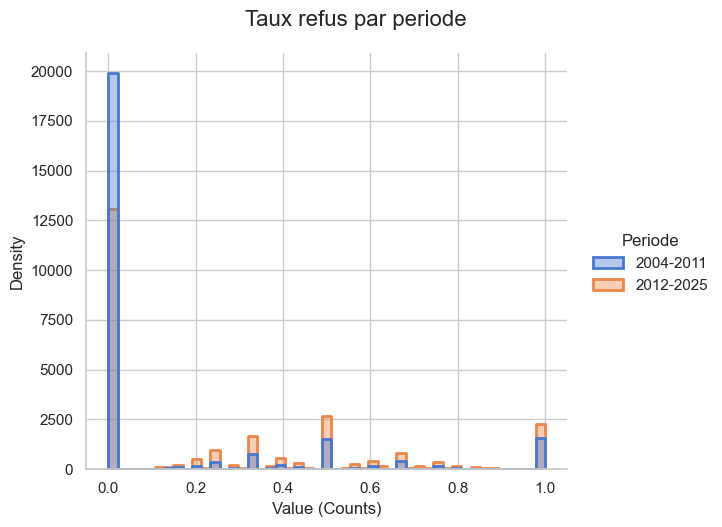


 STATISTICAL TESTING 

>>> Analysis for: All Data

--- Mann-Whitney U Test ---
P-value: 0.00000e+00
Result: Significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.9865      0.017   -118.324      0.000      -2.019      -1.954
period[T.2012-2025]     0.6814      0.021     33.074      0.000       0.641       0.722


In [439]:
period_data, period_data_melt = per_period(data_trans,
                                           bins=[2004, 2012, 2026], 
                                           labels=["2004-2011", "2012-2025"],
                                           analysis="refusal")

plot_dist(period_data_melt, title="Taux refus par periode")
plt.show()

stats_test(period_data_melt, labels=["2004-2011", "2012-2025"])

## Voit-on une augmentation de catnat par type et par commune?

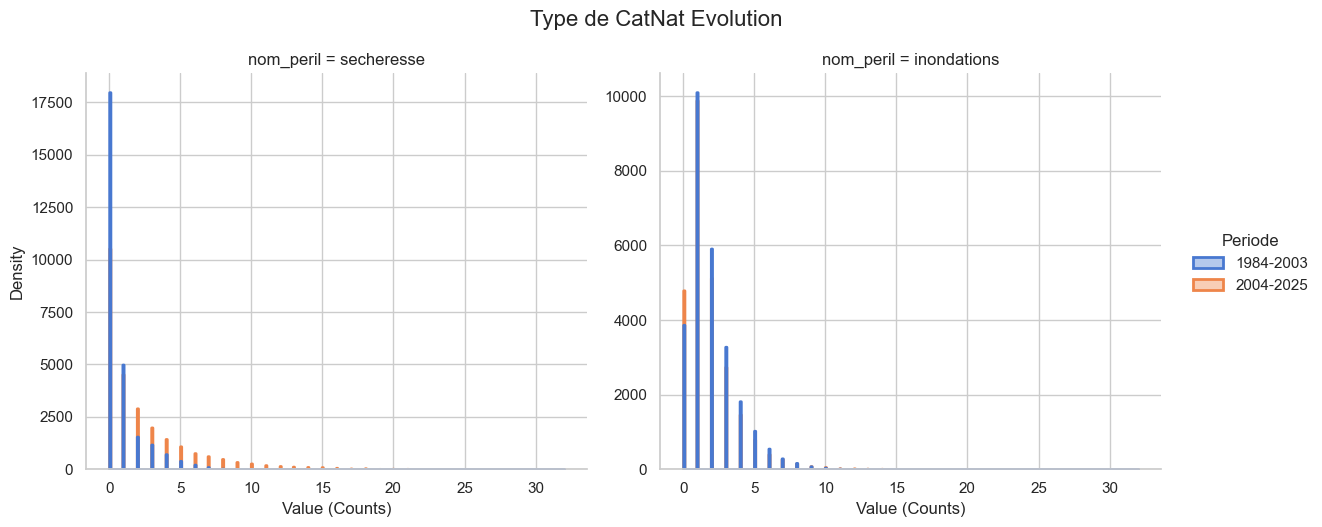


 STATISTICAL TESTING 

>>> Analysis for: secheresse

--- Mann-Whitney U Test ---
P-value: 0.00000e+00
Result: Significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.3653      0.007    -50.178      0.000      -0.380      -0.351
period[T.2004-2025]     1.1836      0.008    141.417      0.000       1.167       1.200

>>> Analysis for: inondations

--- Mann-Whitney U Test ---
P-value: 1.00000e+00
Result: No significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.6571      0.004    150.494      0.000       0.649       0.666
period[T.2004-2025]    -0.0748      0.006    -11.736      0.000      -0.087      -0.062


In [447]:
period_data, period_data_melt = per_period(
    df=data_trans, 
    bins=[1984, 2004, 2026],     
    labels=["1984-2003", "2004-2025"],
    par_peril=True
)

g = plot_dist(
    df=period_data_melt,
    col="nom_peril",
    title="Type de CatNat Evolution"
)
plt.show()

stats_test(
    df=period_data_melt,
    labels=["1984-2003", "2004-2025"],
    group_by_col="nom_peril"
)

## Voit-on un taux de refus plus elevée selon le type de catnat?

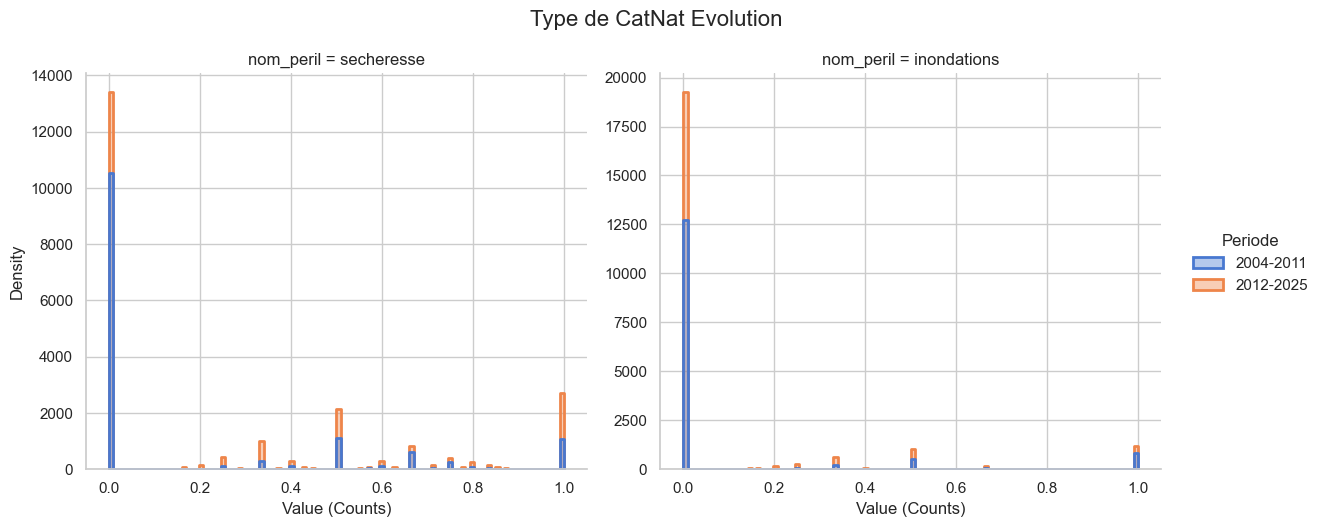


 STATISTICAL TESTING 

>>> Analysis for: secheresse

--- Mann-Whitney U Test ---
P-value: 6.28161e-158
Result: Significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.6968      0.019    -87.434      0.000      -1.735      -1.659
period[T.2012-2025]     0.4039      0.023     17.468      0.000       0.359       0.449

>>> Analysis for: inondations

--- Mann-Whitney U Test ---
P-value: 8.77738e-28
Result: Significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -2.4603      0.028    -86.546      0.000      -2.516      -2.405
period[T.2012-2025]     0.1387      0.035      3.923      0.000       0.069       0.208


In [449]:
period_data, period_data_melt = per_period(
    df=data_trans, 
    bins=[2004, 2012, 2026],     
    labels=["2004-2011", "2012-2025"],
    par_peril=True,
    analysis="refusal"
)

g = plot_dist(
    df=period_data_melt,
    col="nom_peril",
    title="Type de CatNat Evolution"
)
plt.show()

stats_test(
    df=period_data_melt,
    labels=["2004-2011", "2012-2025"],
    group_by_col="nom_peril"
)

In [451]:
refus_inondations = period_data_melt[period_data_melt['nom_peril'] == 'inondations']['value']
refus_secheresse = period_data_melt[period_data_melt['nom_peril'] == 'secheresse']['value']

stat, p_value = stats.mannwhitneyu(refus_inondations, refus_secheresse, alternative='two-sided')

print(f"Statistique U : {stat}")
print(f"P-value : {p_value:.4e}")

alpha = 0.05
if p_value < alpha:
    print("Verdict : Différence statistiquement significative.")
    if refus_inondations.mean() > refus_secheresse.mean():
        print("Les inondations ont un taux de refus moyen plus élevé.")
    else:
        print("La sécheresse a un taux de refus moyen plus élevé.")
else:
    print("Verdict : Pas de différence significative entre les deux distributions.")

Statistique U : 550762609.5
P-value : 0.0000e+00
Verdict : Différence statistiquement significative.
La sécheresse a un taux de refus moyen plus élevé.


## Voit-on une augmentation de la frequence des CatNat par communes? 

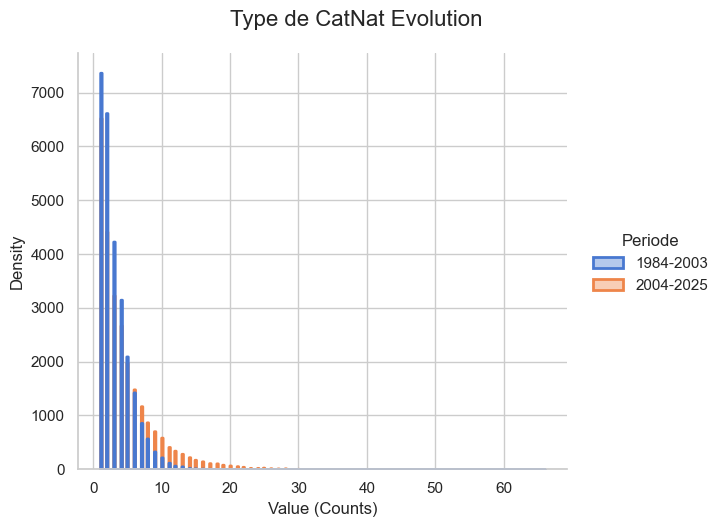


 STATISTICAL TESTING 

>>> Analysis for: All Data

--- Mann-Whitney U Test ---
P-value: nan
Result: No significant increase

--- Poisson GLM ---
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               1.1364      0.003    330.761      0.000       1.130       1.143
period[T.2004-2025]     0.3632      0.005     80.351      0.000       0.354       0.372


In [10]:
durations = {
    "1984-2003": 2004 - 1984,
    "2004-2025": 2026 - 2004  
}

period_data, period_data_melt = per_period(
    df=data_trans, 
    bins=[1984, 2004, 2026],     
    labels=["1984-2003", "2004-2025"],
)


period_data_melt["annual_freq"] = period_data_melt.apply(
    lambda x: x["value"] / durations[x["period"]], axis=1
)

freq_per_period = period_data_melt[period_data_melt["value"]>0]


g = plot_dist(
    df=freq_per_period,
    title="Type de CatNat Evolution"
)
plt.show()

stats_test(
    df=freq_per_period,
    labels=["2004-2011", "2012-2025"],
)

## Création de Variables

### Correlation entre Taux de Refus et Secheresse

In [11]:
catnat_per_peril, _ = per_period(
    df=data_trans, 
    bins=[2004, 2012, 2026],     
    labels=["2004-2011", "2012-2025"],
    par_peril=True,
)

catnat_per_peril = catnat_per_peril.reset_index(level=1, drop=True)
catnat_per_peril = catnat_per_peril.groupby("code_geo").sum()
catnat_per_peril["total"] = catnat_per_peril[["secheresse", "autre", "inondations"]].sum(axis=1)
catnat_per_peril["share_secheresse"] = catnat_per_peril["secheresse"]/catnat_per_peril["total"]
catnat_per_peril["share_inondations"] = catnat_per_peril["inondations"]/catnat_per_peril["total"]

filter_data = data_trans[data_trans["date_debut_evenement"].dt.year > 2003]
catnat_counts = (
    filter_data.groupby("code_geo").size()
)

refused_counts = (
            filter_data[filter_data["libelle_avis"] != "Reconnue"]
            .groupby("code_geo")
            .size()
        )

refus_rate = refused_counts.divide(catnat_counts).fillna(0)
refus_rate.name = "taux_refus"

corr_sech = catnat_per_peril.merge(refus_rate, left_index=True, right_index=True)
corr_sech_plot = corr_sech[(corr_sech["taux_refus"]>0) & 
                  (corr_sech["share_secheresse"]>0) &
                  (corr_sech["total"]>1)]

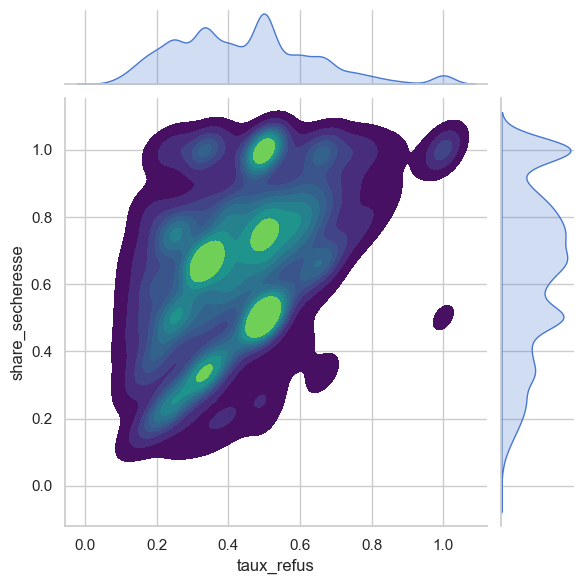

In [13]:
sns.jointplot(data=corr_sech_plot, 
              x="taux_refus", 
              y="share_secheresse", 
              kind="kde", 
              fill=True, 
              cmap="viridis")

### Analyse de la durée des CatNat 

In [14]:
def max_consecutive_years(grp):
    years = sorted(grp["year"].unique())
    if not years:
        return 0

    max_streak = 1
    current_streak = 1
    for i in range(1, len(years)):
        if years[i] == years[i - 1] + 1:
            current_streak += 1
        else:
            max_streak = max(max_streak, current_streak)
            current_streak = 1
    return max(max_streak, current_streak)

def get_max_consecutive_refusals(group):
    group = group.sort_values("date_debut_evenement")
    refused = (group["libelle_avis"] != "Reconnue").astype(int)
    blocks = (refused != refused.shift()).cumsum()
    streaks = refused.groupby(blocks).cumsum()
    return streaks.max()

def duration_features(df):
    ddf = df.copy()
    ddf = ddf[ddf["date_debut_evenement"].dt.year > 2003]
    ddf["year"] = ddf["date_debut_evenement"].dt.year
    
    years_with_events = ddf[["code_geo", "year"]].drop_duplicates()
    consecutive_years = years_with_events.groupby("code_geo").apply(max_consecutive_years)
    
    duration_df = consecutive_years.to_frame(name="max_consecutive_events_year")
    
    ddf = ddf.sort_values(["code_geo", "date_debut_evenement"])
    ddf["days_since_last"] = ddf.groupby("code_geo")["date_debut_evenement"].diff().dt.days
    
    duration_df["avg_recovery_days"] = ddf.groupby("code_geo")["days_since_last"].mean()

    duration_df["max_consecutive_refusal"] = ddf.groupby("code_geo").apply(
        get_max_consecutive_refusals
    )

    return duration_df#.fillna(0)

In [15]:
duration_df = duration_features(data_trans)
duration_df_plot = duration_df[(duration_df["max_consecutive_events_year"] > 1)]
duration_df_plot.head()

,max_consecutive_events_year,avg_recovery_days,max_consecutive_refusal
code_geo,,,
01004,5,861.0,2
01007,5,852.0,1
01012,2,685.0,1
01014,2,275.0,0
01016,2,366.0,0


<Axes: >

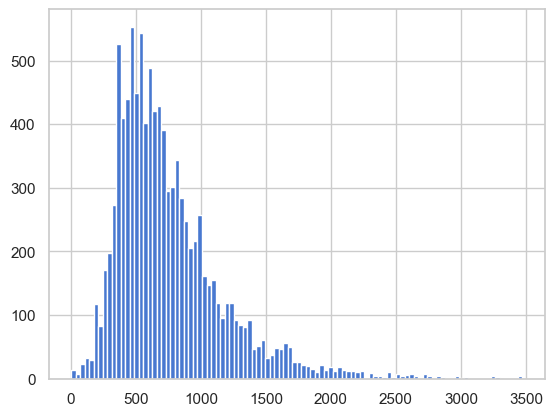

In [16]:
duration_df_plot["avg_recovery_days"].hist(bins=100)

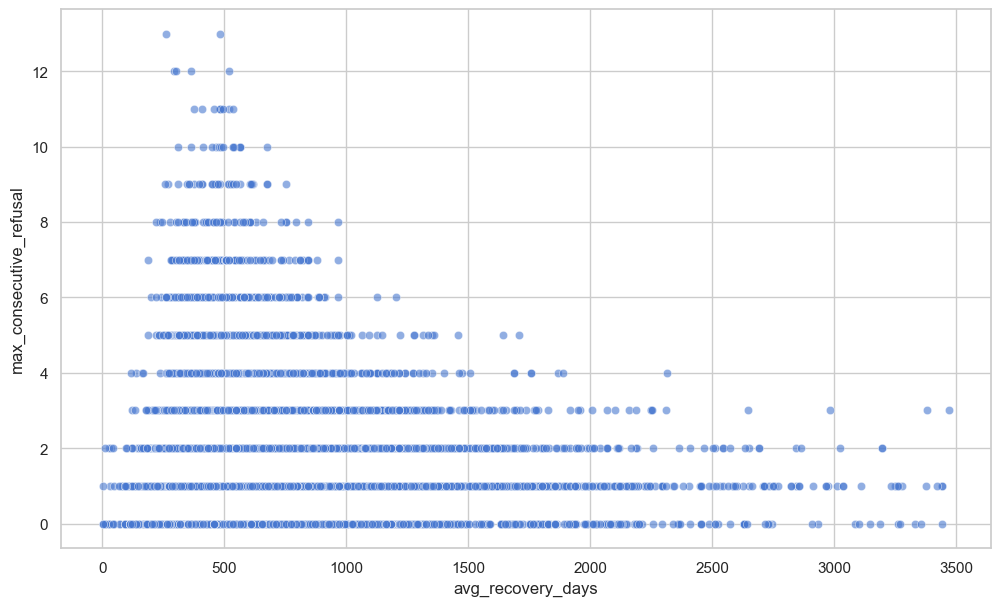

In [17]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=duration_df_plot,
    x="avg_recovery_days",
    y="max_consecutive_refusal",
    alpha=0.6
)

plt.show()

### Analyse Franchise

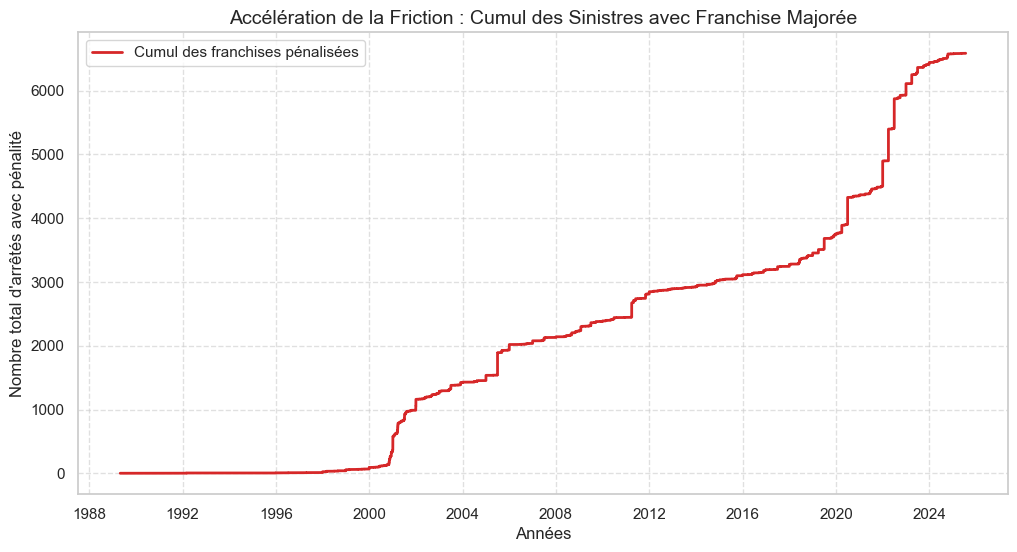

In [18]:
penalty_df = data_trans[(data_trans["franchise"] != "Simple") & (data_trans["libelle_avis"] == "Reconnue")].copy()

penalty_df = penalty_df.sort_values("date_debut_evenement")

penalty_df['total_penalties'] = range(1, len(penalty_df) + 1)

plt.figure(figsize=(12, 6))
plt.step(penalty_df['date_debut_evenement'], penalty_df['total_penalties'], 
         where='post', color='#d62728', linewidth=2, label="Cumul des franchises pénalisées")

plt.title("Accélération de la Friction : Cumul des Sinistres avec Franchise Majorée", fontsize=14)
plt.xlabel("Années")
plt.ylabel("Nombre total d'arrêtés avec pénalité")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [19]:
franchise_df = data_trans[(data_trans["code_geo"].isin(duration_df[duration_df["max_consecutive_events_year"] > 5].index)) &
                          (data_trans["libelle_avis"] == "Reconnue")]
franchise_df.head()

,code_geo,nom_commune,date_debut_evenement,date_fin_evenement,date_arrete,date_parution_jo,nom_peril,franchise,libelle_avis,code_arrete
231,81038,BRENS,2025-08-13,2025-08-13,2025-12-11,2025-12-12,inondations,Simple,Reconnue,902
319,13043,GIGNAC LA NERTHE,2025-09-21,2025-09-22,2025-11-24,2025-12-02,inondations,Simple,Reconnue,900
330,24138,COULOUNIEIX CHAMIERS,2025-05-22,2025-06-24,2025-11-24,2025-12-02,autre,Simple,Reconnue,900
356,45232,OLIVET,2025-03-18,2025-03-18,2025-11-24,2025-12-02,autre,Simple,Reconnue,900
390,69271,CHASSIEU,2025-06-30,2025-07-01,2025-11-24,2025-12-02,inondations,Simple,Reconnue,900


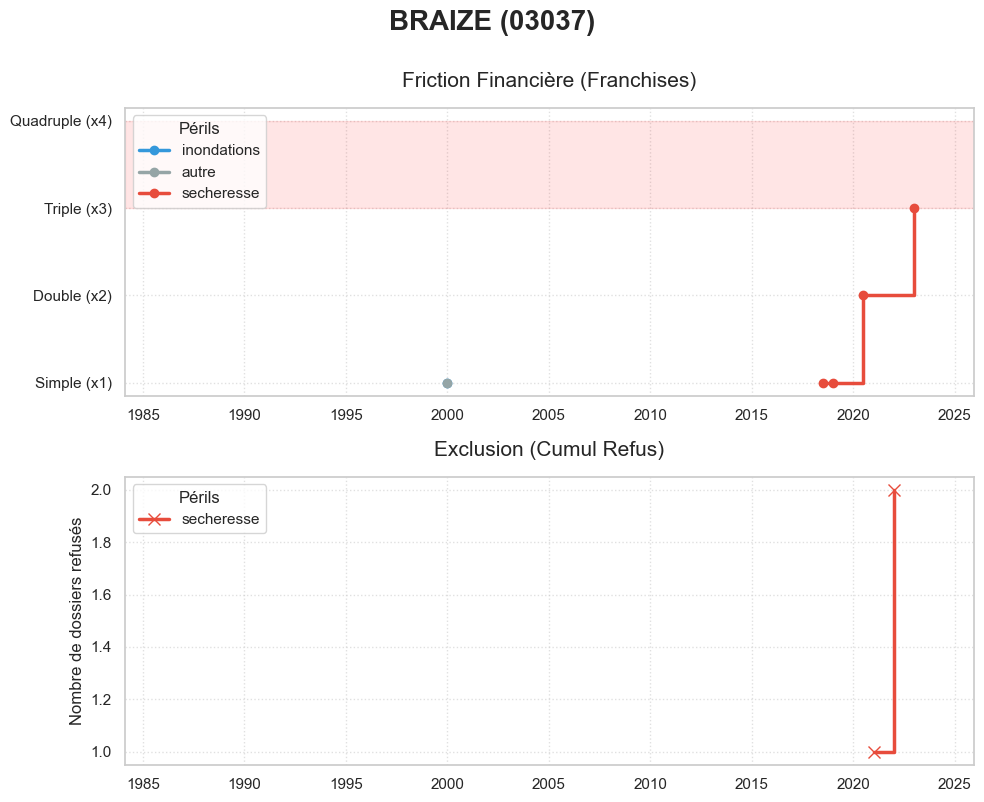

In [20]:
def plot_commune_analysis_side_by_side(df, code_insee):
    commune_all = df[df["code_geo"] == code_insee].copy()
    nom_commune = commune_all["nom_commune"].unique()[0]
    pprns = commune_all[["code_modele", "libelle_procedure"]].drop_duplicates()["code_modele"]
    date_approbations = commune_all["approbation"].unique()
    
    commune_reconnue = commune_all[commune_all["libelle_avis"] == "Reconnue"].sort_values("date_debut_evenement")
    mapping = {"Simple": 1, "Doublée": 2, "Triplée": 3, "Quadruplée": 4}
    commune_reconnue['multiplier'] = commune_reconnue['franchise'].map(mapping).fillna(1)
    
    commune_refus = commune_all[commune_all["libelle_avis"] != "Reconnue"].sort_values("date_debut_evenement")
    commune_refus['cum_refus'] = commune_refus.groupby('nom_peril').cumcount() + 1

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False)
    fig.suptitle(f"{nom_commune} ({code_insee})", fontsize=20, fontweight='bold', y=1)

    color_map = {
        'Sécheresse': '#e74c3c', 
        'Inondation': '#3498db',
        'Autre': '#95a5a6'      
    }

    def get_color(peril_name):
        if 'secheresse' in peril_name.lower(): return color_map['Sécheresse']
        if 'inondation' in peril_name.lower(): return color_map['Inondation']
        return color_map['Autre']

    # --- GRAPH 1 : ESCALADE DES FRANCHISES ---
    perils_f = commune_reconnue['nom_peril'].unique()
    
    for i, peril in enumerate(perils_f):
        subset = commune_reconnue[commune_reconnue['nom_peril'] == peril]
        ax1.plot(subset['date_debut_evenement'], subset['multiplier'], 
                 label=f"{peril}", color=get_color(peril), marker='o', linewidth=2.5, drawstyle='steps-post')

    ax1.set_title("Friction Financière (Franchises)", fontsize=15, pad=15)
    ax1.set_yticks([1, 2, 3, 4])
    ax1.set_yticklabels(['Simple (x1)', 'Double (x2)', 'Triple (x3)', 'Quadruple (x4)'])
    ax1.axhspan(3, 4, color='red', alpha=0.1)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(title="Périls", loc='upper left')

    if not pd.isna(pprns.values[0]):
        for pprn, date_approbation in zip(pprns, date_approbations):
            ax1.axvline(date_approbation, linewidth=1.5, linestyle="--", color="black")
            ax1.text(date_approbation + pd.Timedelta(days=150), ax1.get_ylim()[1] * 0.4, 
                     f"Approbation {pprn}", rotation=90)

    # --- GRAPH 2 : CUMUL DES REFUS ---
    if not commune_refus.empty:
        perils_r = commune_refus['nom_peril'].unique()
        
        for i, peril in enumerate(perils_r):
            subset = commune_refus[commune_refus['nom_peril'] == peril]
            ax2.plot(subset['date_debut_evenement'], subset['cum_refus'], 
                     label=f"{peril}", color=get_color(peril), marker='x', markersize=8, linewidth=2.5, drawstyle='steps-post')
        
        ax2.set_title("Exclusion (Cumul Refus)", fontsize=15, pad=15)
        ax2.set_ylabel("Nombre de dossiers refusés")
        ax2.grid(True, linestyle=':', alpha=0.6)
        ax2.legend(title="Périls", loc='upper left')
    else:
        ax2.text(0.5, 0.5, "Aucun refus enregistré", ha='center', va='center', fontsize=14, color='gray')
        ax2.set_title("Exclusion (Aucun Refus)", fontsize=15, pad=15)

    for ax in [ax1, ax2]:
        ax.set_xlabel("")
        ax.set_xlim(df["date_arrete"].min(), df["date_arrete"].max())

    plt.tight_layout()
    plt.show()


pprn_encoded = pd.get_dummies(
    pprn_df, 
    columns=['code_modele_desc'], 
    prefix='pprn', 
    dtype=int
).set_index("code_geo")
cols = ['approbation',
        'libelle_procedure',
        'code_modele']

data_trans_test = data_trans.set_index("code_geo")\
                            .merge(pprn_df.set_index("code_geo")[cols], left_index=True, right_index=True, how="left")\
                            .reset_index()

top_commune = duration_df[(duration_df["max_consecutive_events_year"] > 5)].index[20]
plot_commune_analysis_side_by_side(data_trans_test, "03037")

In [29]:
def compute_penalty_score(df):
    df = df.copy()
    mapping = {"Simple": 1, "Doublée": 2, "Triplée": 3, "Quadruplée": 4}
    df['mult_val'] = df['franchise'].map(mapping).fillna(1)
    
    penalty_stats = df[df["libelle_avis"] == "Reconnue"].groupby('code_geo').agg(
        avg_penalty=('mult_val', 'mean'),
        max_penalty=('mult_val', 'max'),
        total_sinistres=('mult_val', 'count')
    )
    
    penalty_stats['penalty_friction_index'] = penalty_stats['avg_penalty'] * np.log1p(penalty_stats['total_sinistres'])
    return penalty_stats[['penalty_friction_index']]

### A Risque et pas de PPRN

In [22]:
penality = data_trans.copy()
penality = penality[penality["franchise"] == "Doublée"]

In [23]:
commune_risk = duration_df[(duration_df["max_consecutive_events_year"] >= 5)]
commune_risk = commune_risk.merge(pprn_df.set_index("code_geo")[cols], left_index=True, right_index=True, how="left")
commune_risk = commune_risk[(commune_risk["code_modele"].isna()) & (commune_risk.index.isin(penality['code_geo']))]
commune_risk = commune_risk.reset_index()

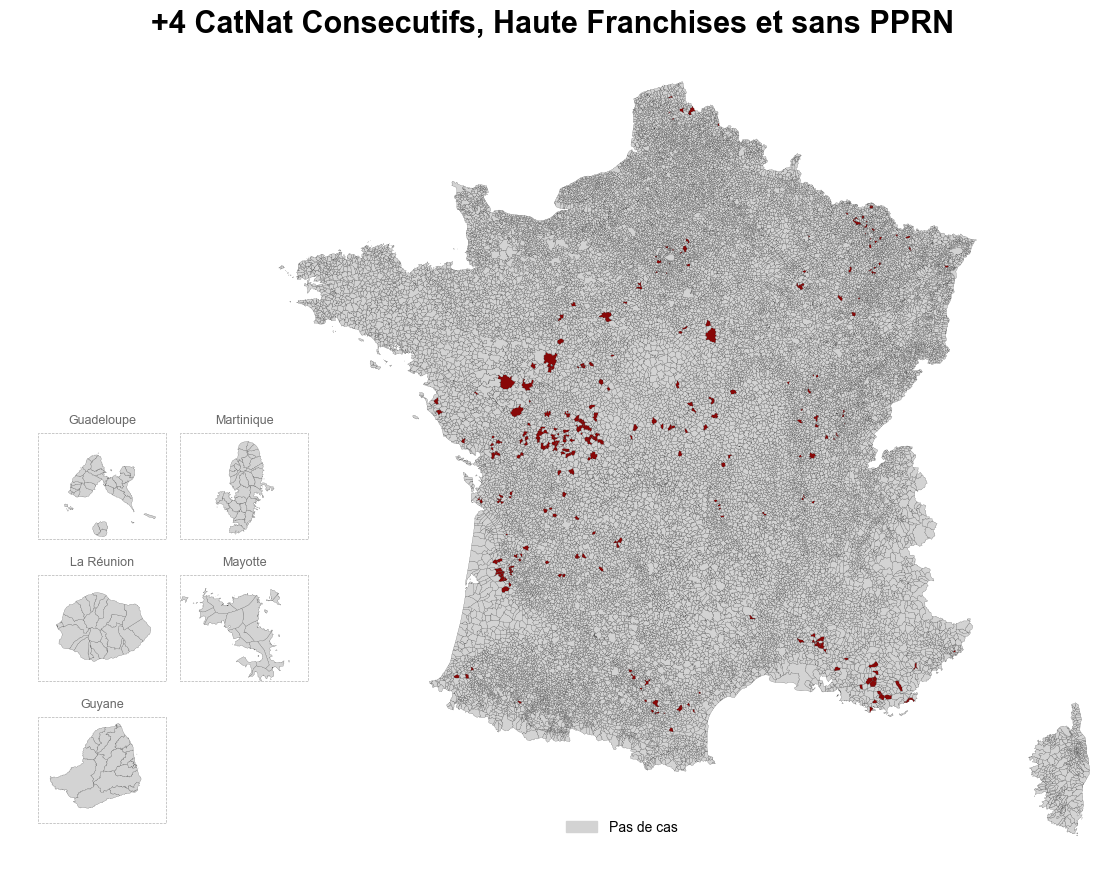

In [24]:
commune_risk_geo = communes_geo.merge(commune_risk.reset_index(), left_on="code", right_on="code_geo", how="left")

custom_red = ListedColormap(["#e74c3c", "#e74c3c"])
monovariate_map(commune_risk_geo, 
                col="max_consecutive_refusal", 
                missing_color="lightgrey",
                cmap=LinearSegmentedColormap.from_list("monochrome", ["#880808", "#880808"]),
                colorbar=False,
                title="+4 CatNat Consecutifs, Haute Franchises et sans PPRN");

### Correlation Matrix

In [30]:
feat_df = corr_sech.merge(duration_df, left_index=True, right_index=True, how="left")\
                   .merge(compute_penalty_score(data_trans), left_index=True, right_index=True, how="left")\
                   .merge(geo_ccr_df[["cout_moy_tout_rank", 
                                      "cout_cumul_tout_rank", 
                                      "prime_tot_rank",
                                      "sp_tout_rank"]], left_index=True, right_index=True, how="left")
feat_df = feat_df.drop(columns=["autre","inondations", "secheresse"])
feat_df.head()

,total,share_secheresse,share_inondations,taux_refus,max_consecutive_events_year,avg_recovery_days,max_consecutive_refusal,penalty_friction_index,cout_moy_tout_rank,cout_cumul_tout_rank,prime_tot_rank,sp_tout_rank
code_geo,,,,,,,,,,,,
01001,1,0.000,1.000,0.000000,1,NaN,0,1.098612,-1.0,-1.0,-1.0,-1.0
01004,8,0.750,0.250,0.375000,5,861.0,2,2.746531,3.0,3.0,-1.0,1.0
01007,8,0.625,0.375,0.125000,5,852.0,1,2.814271,3.0,3.0,-1.0,2.0
01012,3,1.000,0.000,0.333333,2,685.0,1,1.098612,0.0,0.0,-1.0,1.0
01013,1,1.000,0.000,0.000000,1,NaN,0,0.693147,0.0,0.0,-1.0,0.0


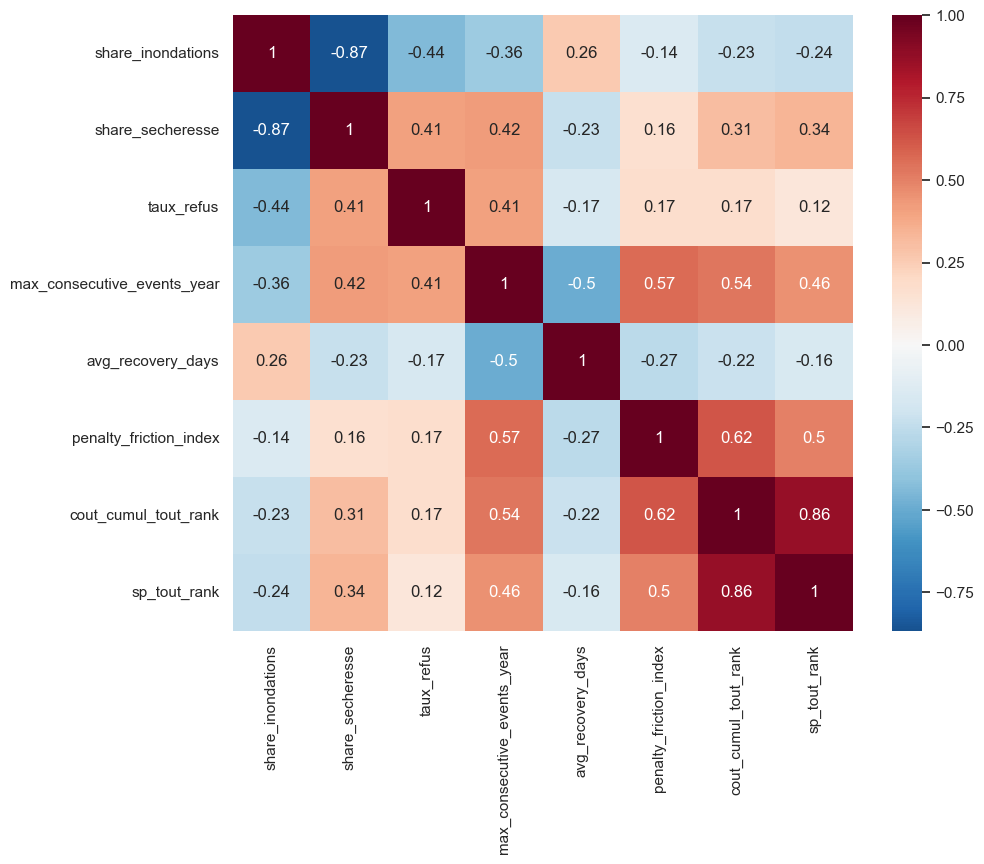

In [31]:
corr_matrix = feat_df[['share_inondations', 'share_secheresse', 
                       'taux_refus', 
                       'max_consecutive_events_year', # => Main predictor
                       'avg_recovery_days',
                       'penalty_friction_index',
                       'cout_cumul_tout_rank',
                       #'cout_moy_tout_rank',
                       'sp_tout_rank']].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0)
plt.title("")
plt.show()

## __CLUSTERING AND MAPPING__

In [32]:
feat_df["avg_recovery_days"] = feat_df["avg_recovery_days"].fillna(365*10)
feat_df["penalty_friction_index"] = feat_df["penalty_friction_index"].fillna(1)
feat_df["cout_cumul_tout_rank"] = feat_df["cout_cumul_tout_rank"].fillna(0)
feat_df["cout_moy_tout_rank"] = feat_df["cout_moy_tout_rank"].fillna(0)
feat_df["sp_tout_rank"] = feat_df["sp_tout_rank"].fillna(0)

cols = ['share_inondations', 'share_secheresse', 
         'taux_refus', 
         #'max_consecutive_refusal', #=> Main predictor
         'max_consecutive_events_year',
         'avg_recovery_days',
         'penalty_friction_index',
         'cout_cumul_tout_rank',
         #'cout_moy_tout_rank',
         #'prime_tout_rank'
         'sp_tout_rank'
         ]

scaler = RobustScaler()

scaler = scaler.fit(feat_df[cols])
feat_df_scaled = scaler.transform(feat_df[cols])

### __KMEANS__

In [35]:
np.random.seed(42)

range_n_clusters = list(range(2, 11))
silhouette_avg_scores = []
best_k = 0
max_silhouette = -1

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = clusterer.fit_predict(feat_df_scaled) 
    
    silhouette_avg = davies_bouldin_score(feat_df_scaled, cluster_labels) #davies_bouldin_score, silhouette_score
    silhouette_avg_scores.append(silhouette_avg)
    
    if silhouette_avg > max_silhouette:
        max_silhouette = silhouette_avg
        best_k = n_clusters
        
    print(f"Pour n_clusters = {n_clusters}, le Silhouette Score moyen est : {silhouette_avg:.4f}")

print(f"\n---> Le nombre optimal de clusters est {best_k} avec un score de {max_silhouette:.4f}")

Pour n_clusters = 2, le Silhouette Score moyen est : 0.9381
Pour n_clusters = 3, le Silhouette Score moyen est : 1.1183
Pour n_clusters = 4, le Silhouette Score moyen est : 1.1911
Pour n_clusters = 5, le Silhouette Score moyen est : 1.2757
Pour n_clusters = 6, le Silhouette Score moyen est : 1.1704
Pour n_clusters = 7, le Silhouette Score moyen est : 1.2021
Pour n_clusters = 8, le Silhouette Score moyen est : 1.2068
Pour n_clusters = 9, le Silhouette Score moyen est : 1.1488
Pour n_clusters = 10, le Silhouette Score moyen est : 1.1903

---> Le nombre optimal de clusters est 5 avec un score de 1.2757


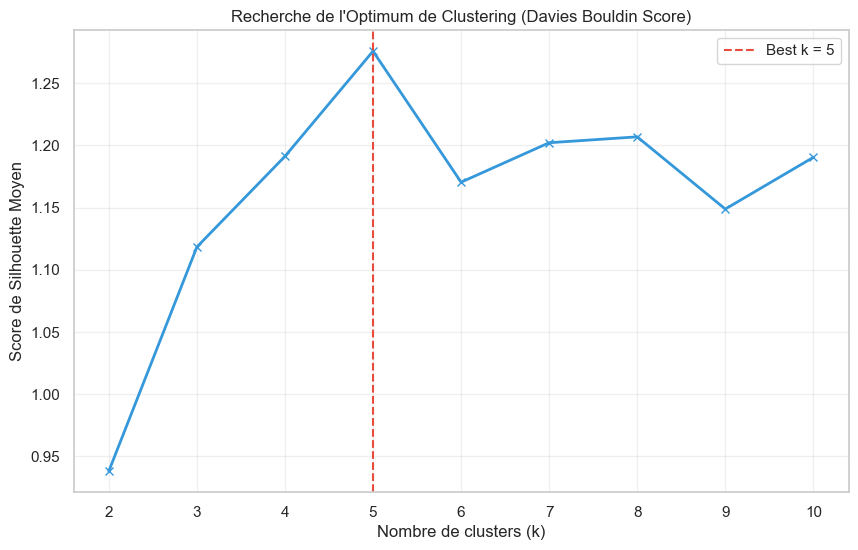

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg_scores, 'bx-', color='#3498db', linewidth=2)
plt.axvline(x=best_k, color='#e74c3c', linestyle='--', label=f'Best k = {best_k}')

plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score de Silhouette Moyen')
plt.title('Recherche de l\'Optimum de Clustering (Davies Bouldin Score)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### _CONFORMALIZE_

In [39]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=42)
final_labels = kmeans.fit_predict(feat_df_scaled)
centroids = kmeans.cluster_centers_
distances_all = np.linalg.norm(feat_df_scaled[:, np.newaxis] - centroids, axis=2)

p_values_matrix = np.zeros(distances_all.shape)

for k in range(best_k):
    dist_k_reference = distances_all[final_labels == k, k]
    p_values_matrix[:, k] = np.array([np.mean(dist_k_reference >= d) for d in distances_all[:, k]])

df_pvals = pd.DataFrame(
    p_values_matrix, 
    columns=[f'p_val_cluster_{i}' for i in range(best_k)],
    index=feat_df.index
)

feat_df = pd.concat([feat_df, df_pvals], axis=1)
feat_df['kmeans_cluster'] = final_labels

In [62]:
def get_soft_labels(p_matrix):
    row_sums = p_matrix.sum(axis=1, keepdims=True)
    weights = np.divide(p_matrix, row_sums, out=np.zeros_like(p_matrix), where=row_sums!=0)
    cluster_indices = np.arange(p_matrix.shape[1])
    return np.dot(weights, cluster_indices)

feat_df['floating_cluster'] = get_soft_labels(p_values_matrix)

alpha = 0.05
feat_df['prediction_set'] = [
    [i for i, p in enumerate(row) if p > alpha] 
    for row in p_values_matrix
]

feat_df['set_size'] = feat_df['prediction_set'].apply(len)

print(f"Analyse terminée pour {len(feat_df)} communes.")
print(f"Nombre moyen de clusters plausibles par commune : {feat_df['set_size'].mean():.2f}")
print(f"Nombre de communes considérées comme 'Outliers' (p-values < {epsilon}) : {(feat_df['set_size'] == 0).sum()}")

Analyse terminée pour 25864 communes.
Nombre moyen de clusters plausibles par commune : 1.64
Nombre de communes considérées comme 'Outliers' (p-values < 0.05) : 693


In [65]:
# Outliers (-1 clusters)
feat_df.loc[feat_df['set_size'] == 0, "kmeans_cluster"] = -1

In [66]:
ksizes = feat_df.groupby("kmeans_cluster").size()
ksizes

kmeans_cluster
-1     693
 0    6064
 1     734
 2    4031
 3    5365
 4    8977
dtype: int64

In [68]:
clusters = feat_df.groupby("kmeans_cluster")[cols].mean()
clusters[cols].T.round(3)

kmeans_cluster,-1,0,1,2,3,4
share_inondations,0.662,0.432,0.214,0.280,0.215,0.852
share_secheresse,0.266,0.484,0.737,0.660,0.669,0.050
taux_refus,0.431,0.227,0.542,0.407,0.502,0.063
max_consecutive_events_year,2.215,1.514,8.650,3.700,1.299,1.078
avg_recovery_days,2912.141,1314.885,417.795,635.601,2214.708,2462.250
penalty_friction_index,1.831,2.021,2.952,2.465,1.270,1.476
cout_cumul_tout_rank,1.049,1.981,3.172,2.281,-0.173,-0.064
sp_tout_rank,1.218,2.704,2.940,2.486,-0.008,0.097


In [69]:
minmax = MinMaxScaler()

minmax = minmax.fit(feat_df[cols])

cluster_stats_scaled = pd.DataFrame(
    minmax.transform(clusters[cols]), 
    columns=cols, 
    index=clusters.index
)

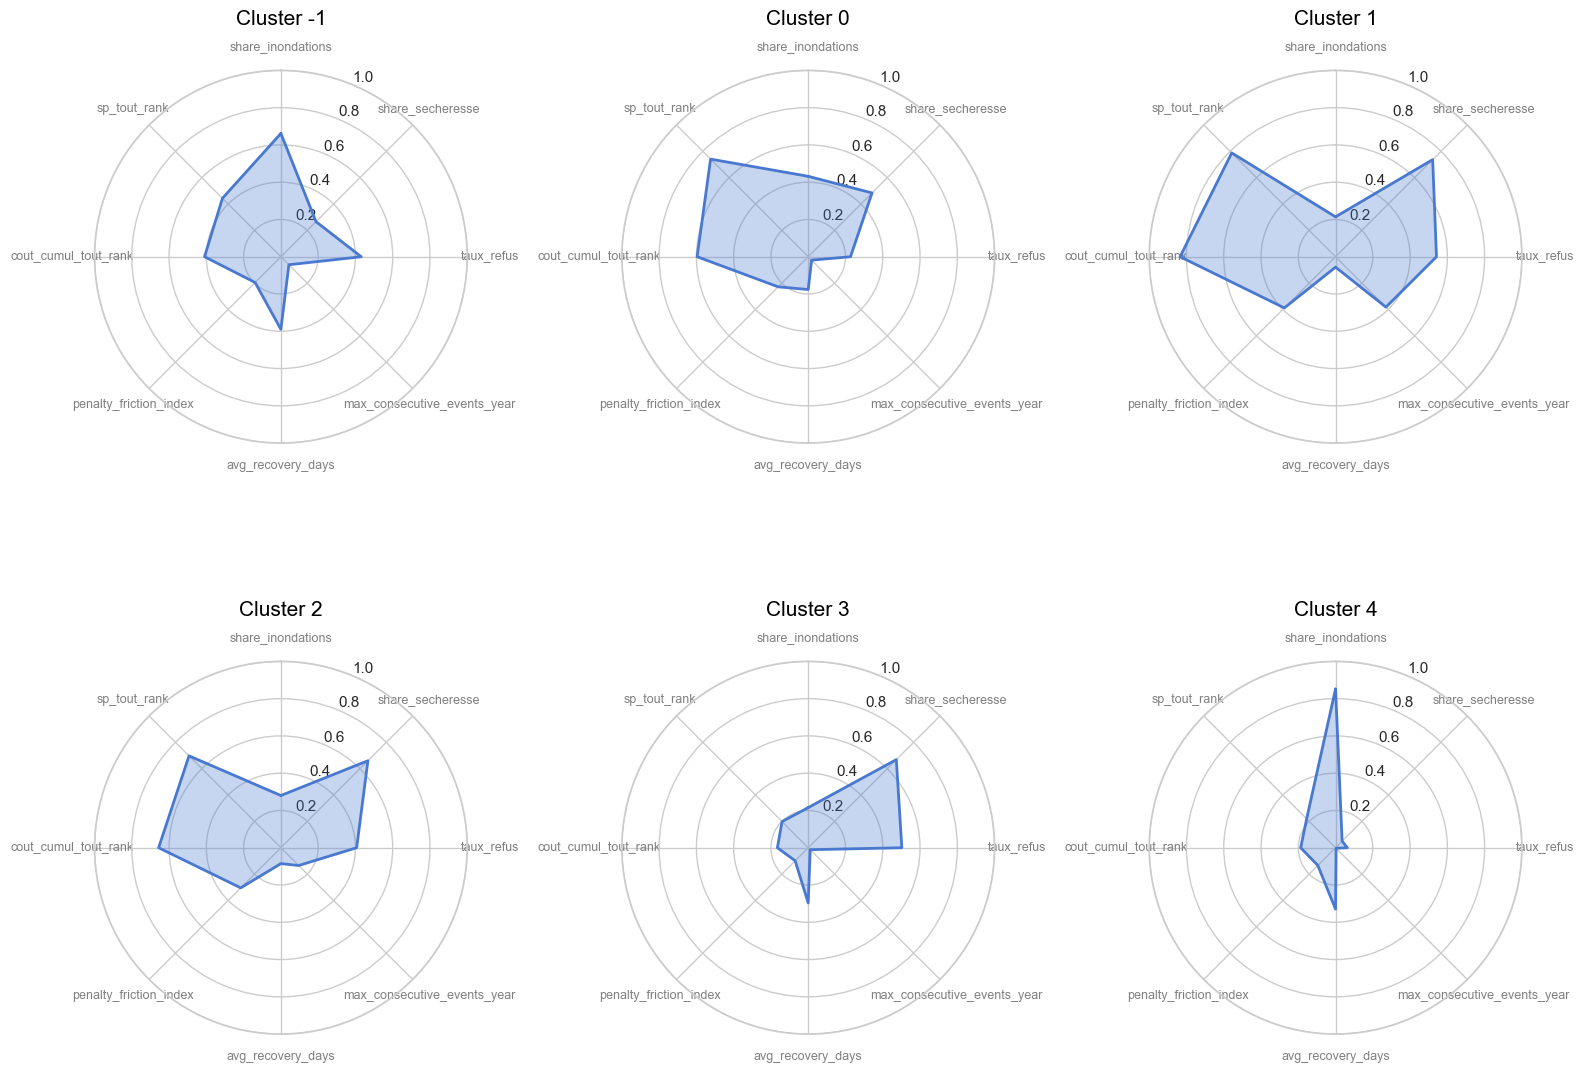

In [70]:
def make_radar_chart(df_scaled):
    categories = list(df_scaled.columns)
    N = len(categories)
    
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1] # Refermer la boucle
    
    fig = plt.figure(figsize=(16, 12))
    plt.subplots_adjust(hspace=0.5)

    for i, cluster in enumerate(df_scaled.index):
        ax = plt.subplot(2, 3, i + 1, polar=True)
        
        values = df_scaled.loc[cluster].values.flatten().tolist()
        values += values[:1]
        
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {cluster}")
        ax.fill(angles, values, alpha=0.3)
        
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        plt.xticks(angles[:-1], categories, color='grey', size=9)
        
        ax.set_title(f"Cluster {cluster}", size=15, color='black', y=1.1)
        ax.set_ylim(0, 1)

    plt.tight_layout()
    return fig

fig_radar = make_radar_chart(cluster_stats_scaled)
plt.show()

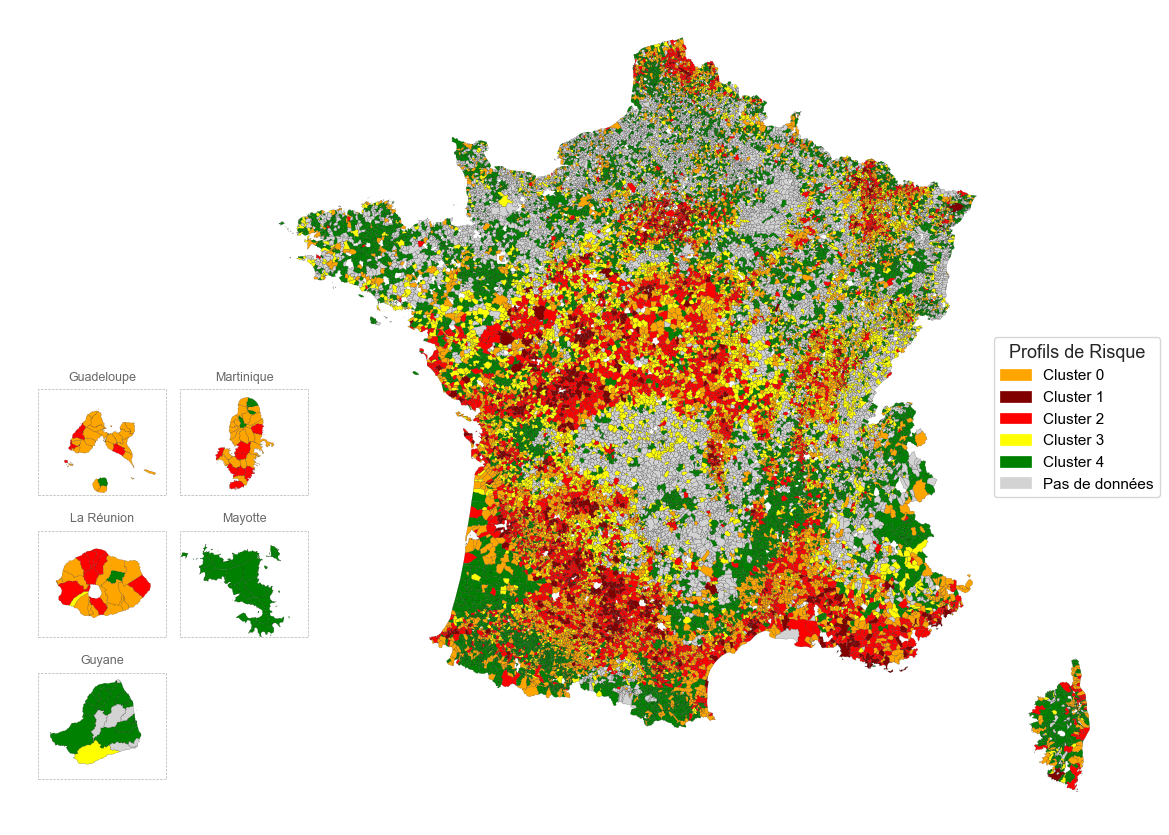

In [78]:
feat_df_geo = communes_geo.merge(feat_df, left_on="code", right_on="code_geo", how="left")

custom_colors = [
    '#FFA500', # Cluster 0
    '#800000', # Cluster 1
    'red', # Cluster 2
    'yellow', # Cluster 3 
    'green'  # Cluster 4 
]

cmap_custom = ListedColormap(custom_colors[:best_k+1])

#custom_red_blue = ListedColormap(["#e74c3c", "#50C878"])
cluster_map(feat_df_geo[feat_df_geo["kmeans_cluster"] != -1], 
            col="kmeans_cluster", 
            missing_color="lightgrey",
            cmap=cmap_custom, 
            title="");

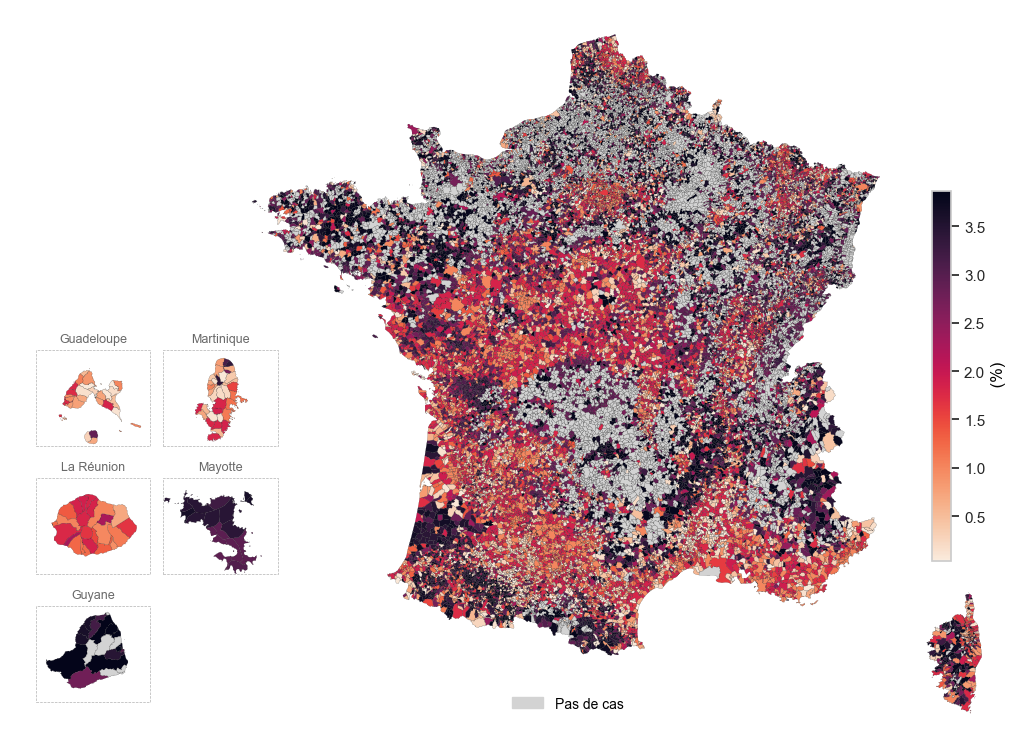

In [74]:
# Most sort value by risk
monovariate_map(feat_df_geo, 
                col="floating_cluster", 
                missing_color="lightgrey",
                cmap="rocket_r", 
                title="");

### __PCA__

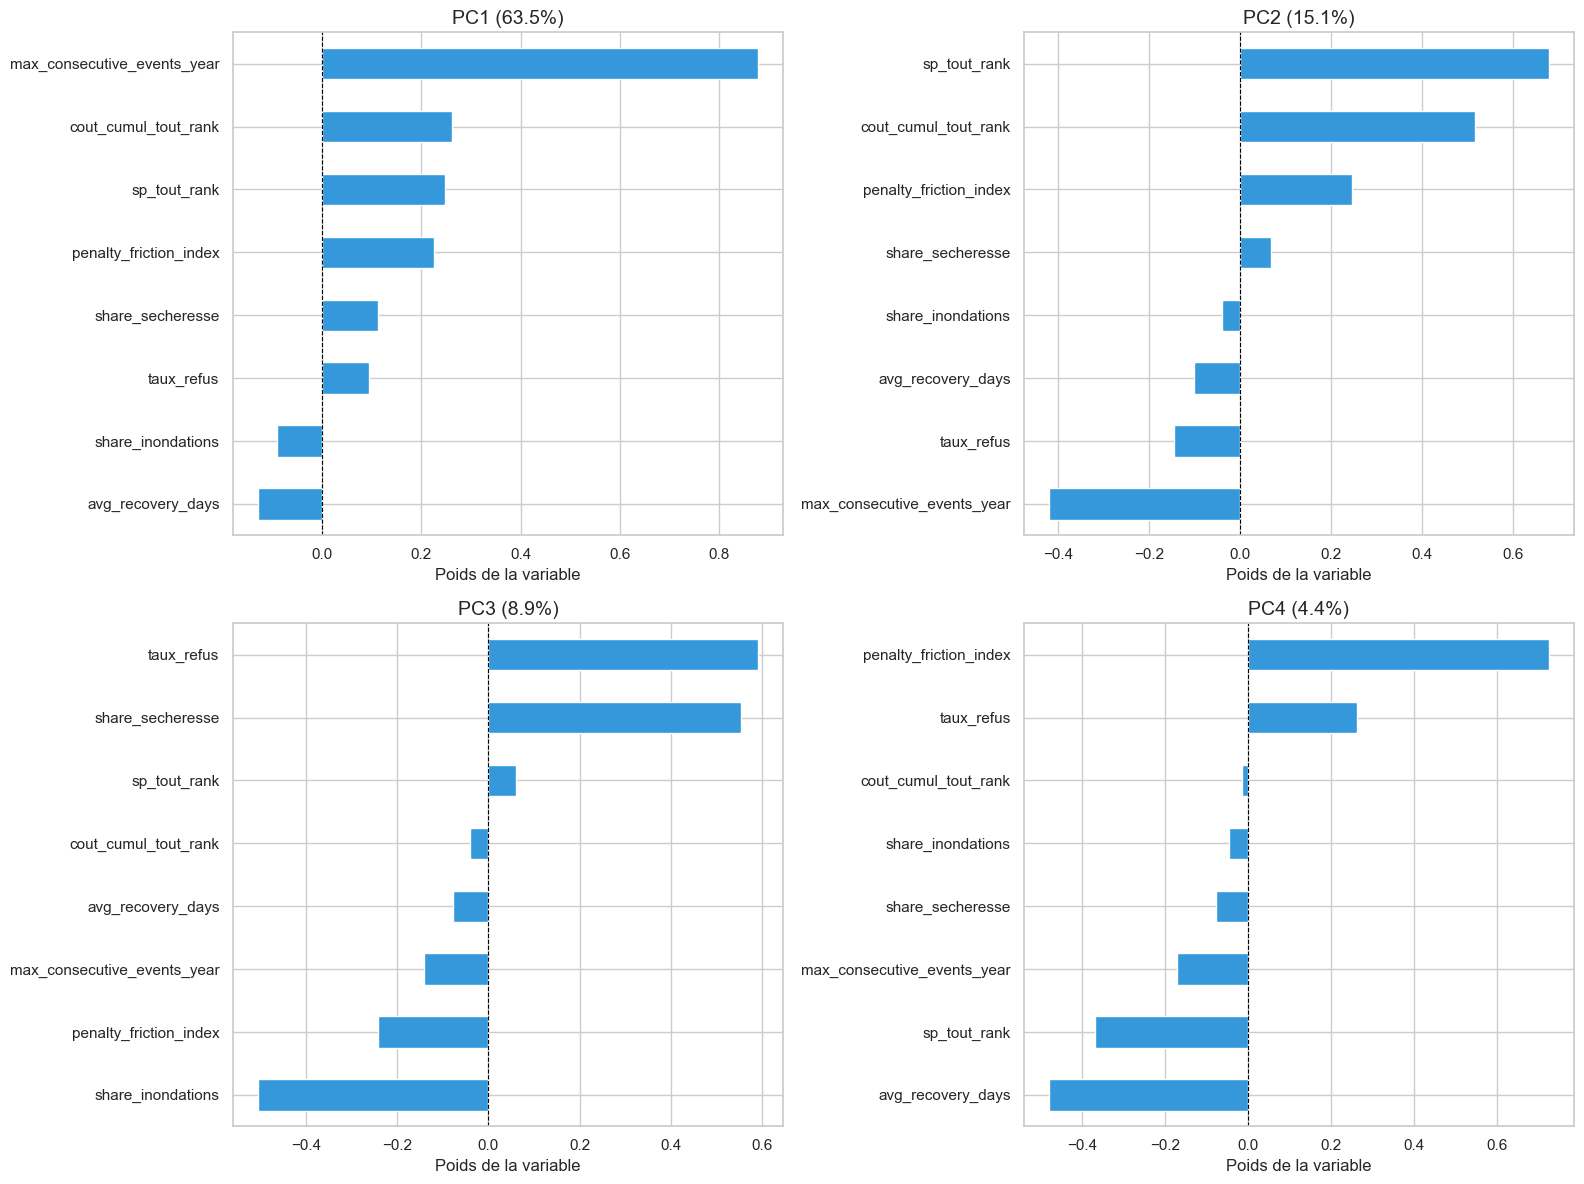

<Figure size 640x480 with 0 Axes>

In [57]:
n_components = 4
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(feat_df_scaled)

pca_cols = [f"PC{n_component+1}" for n_component in range(n_components)]

pca_df = pd.DataFrame(X_pca, columns=pca_cols, index=feat_df.index)
pca_df['kmeans_cluster'] = feat_df['kmeans_cluster'] 

# 4. Visualisation de la Projection (PC1 vs PC2)
"""
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df, x='PC1', y='PC2', 
    hue='kmeans_cluster',
    palette='viridis', alpha=0.7, s=80
)
"""

# 5. Extraction et Plot des Loadings (Contributions)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=pca_cols, 
    index=cols
)

half = int(n_components/2)
fig, axs = plt.subplots(half, 2, figsize=(16, 12))
axs = axs.flatten()

for i in range(n_components):
    loadings_sorted = loadings[f'PC{i+1}'].sort_values()
    
    loadings_sorted.plot(kind='barh', ax=axs[i], color='#3498db')
    
    axs[i].set_title(f'PC{i+1} ({pca.explained_variance_ratio_[i]:.1%})', fontsize=14)
    axs[i].axvline(0, color='black', lw=0.8, linestyle='--')
    axs[i].set_xlabel('Poids de la variable')
    axs[i].set_ylabel('')

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

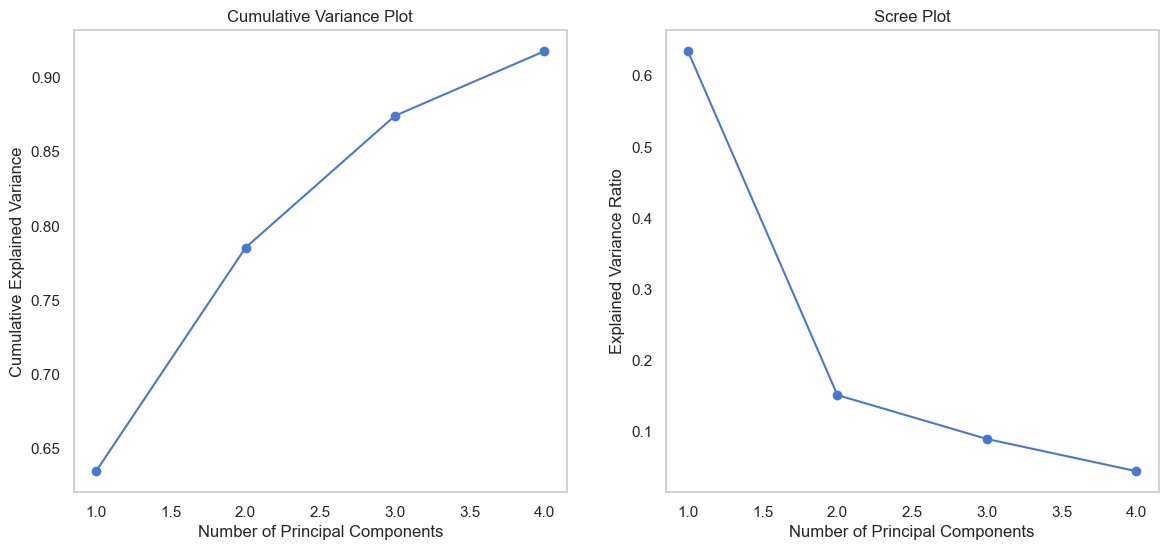

Optimal number of components: 1


In [56]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

optimal_k = np.argmax(cumulative_variance >= 0.95) + 1 

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='-')
axes[0].set_xlabel("Number of Principal Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].set_title("Cumulative Variance Plot")
axes[0].grid()

axes[1].plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='-', label="Explained Variance per Component")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Explained Variance Ratio")
axes[1].set_title("Scree Plot")
axes[1].grid()

plt.show()

print(f"Optimal number of components: {optimal_k}")

In [1930]:
fig = px.scatter_3d(
    pca_df, x='PC1', y='PC2', z='PC3',
    color='cluster',
    hover_name=pca_df.index, # Affiche le nom de la commune au survol
    title=f"Visualisation 3D (Variance Totale: {sum(pca.explained_variance_ratio_[:3]):.1%})",
    labels={'PC1': 'Gravité', 'PC2': 'Type de Péril', 'PC3': 'Dynamique'},
    opacity=0.7
)

fig.update_traces(marker=dict(size=5))
fig.write_html("pca_3d.html")

### __DBSCAN__

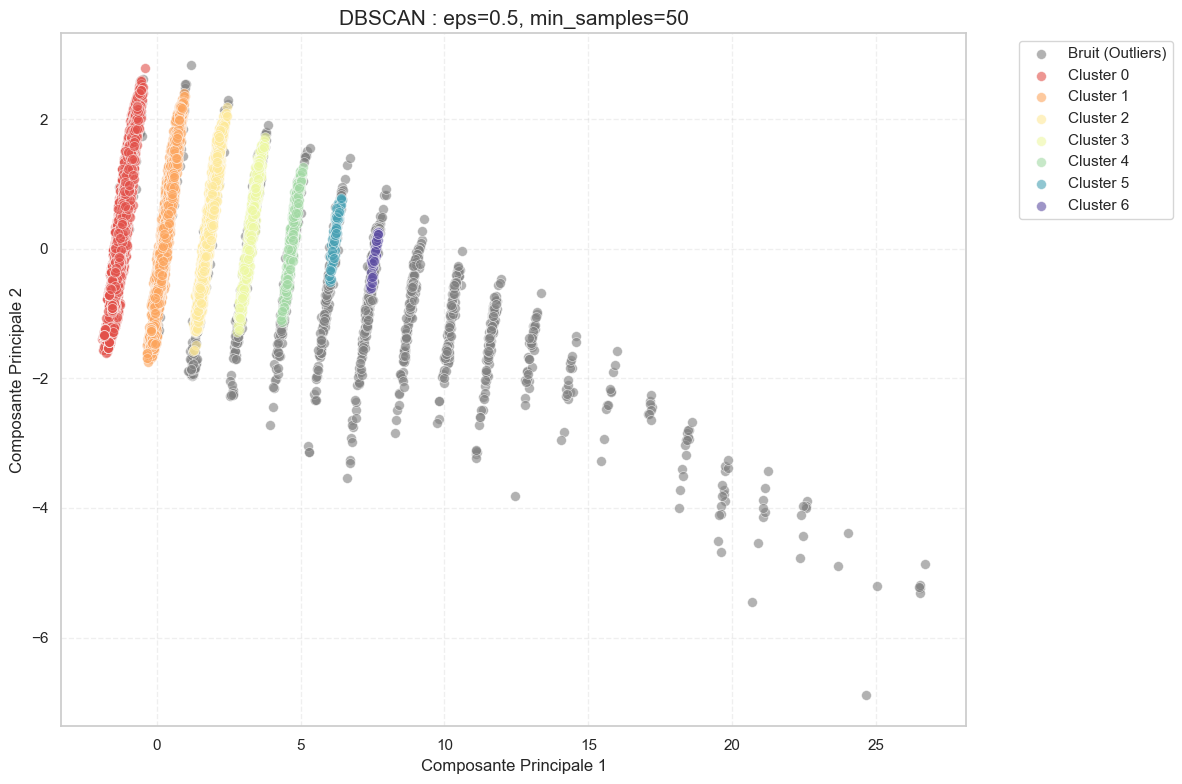

In [1931]:
X_pca_arr = np.array(X_pca)
X_unique_arr, inverse_indices = np.unique(X_pca_arr, axis=0, return_inverse=True)

clusterer = DBSCAN(
    eps=0.5,           
    min_samples=50,    
    n_jobs=-1
)

unique_labels = clusterer.fit_predict(X_unique_arr)

full_labels = unique_labels[inverse_indices]

feat_df['dbscan_cluster'] = full_labels

feat_df['cluster_prob'] = [1 if l != -1 else 0 for l in full_labels]

plt.figure(figsize=(12, 8))

unique_clusters = sorted(set(full_labels))
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_clusters))]

for k, col in zip(unique_clusters, colors):
    if k == -1:
        col = [0.5, 0.5, 0.5, 0.3] # Gris pour le bruit
    
    class_member_mask = (full_labels == k)
    xy = X_pca_arr[class_member_mask] 
    
    if len(xy) > 0:
        plt.scatter(xy[:, 0], xy[:, 1], 
                    color=[col], 
                    label=f'Cluster {k}' if k != -1 else 'Bruit (Outliers)',
                    s=50, alpha=0.6, edgecolor='w', linewidth=0.5)

plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.title(f"DBSCAN : eps=0.5, min_samples=50", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [1932]:
clusters = feat_df.groupby("dbscan_cluster").mean()
clusters.T.round(3)

dbscan_cluster,-1,0,1,2,3,4,5,6
total,13.898,2.264,5.372,7.851,10.193,11.975,14.057,15.672
share_secheresse,0.668,0.277,0.506,0.655,0.692,0.693,0.770,0.788
share_inondations,0.267,0.622,0.405,0.285,0.255,0.258,0.194,0.182
taux_refus,0.499,0.203,0.310,0.374,0.454,0.470,0.532,0.578
max_consecutive_events_year,6.917,1.000,2.000,3.000,4.000,5.000,6.000,7.000
avg_recovery_days,580.437,2496.671,914.691,696.501,605.882,539.804,468.743,436.175
max_consecutive_refusal,3.423,0.446,1.284,1.947,2.664,3.038,3.582,4.246
penalty_friction_index,2.805,1.459,1.960,2.326,2.466,2.620,2.742,2.663
cout_moy_tout_rank,0.354,-0.479,-0.128,0.179,0.348,0.519,0.993,0.918
cout_cumul_tout_rank,2.456,0.288,1.249,1.987,2.477,2.908,3.504,3.426


### Conformal Prediction